<a href="https://colab.research.google.com/github/OlenaBogoliubova/DATA-LOVE-ACADEMY/blob/main/HW_2_4_%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%B8_%D0%B1%D1%83%D1%81%D1%82%D0%B8%D0%BD%D0%B3%D1%83_Bogoliubova.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням алгоритмів бустингу: XGBoost та LightGBM, а також використаємо бібліотеку HyperOpt для оптимізації гіперпараметрів.

0. Зчитайте дані `train.csv` в змінну `raw_df` та скористайтесь наведеним кодом нижче аби розділити дані на трнувальні та валідаційні і розділити дані на ознаки з матириці Х та цільову змінну. Назви змінних `train_inputs, train_targets, train_inputs, train_targets` можна змінити на ті, які Вам зручно.

  Наведений скрипт - частина отриманого мною скрипта для обробки даних. Ми тут не викнуємо масштабування та обробку категоріальних змінних, бо хочемо це делегувати алгоритмам, які будемо використовувати. Якщо щось не розумієте в наведених скриптах, рекомендую розібратись: навичка читати код - важлива складова роботи в машинному навчанні.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from typing import Tuple, Dict, Any


def split_train_val(df: pd.DataFrame, target_col: str, test_size: float = 0.2, random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split the dataframe into training and validation sets.

    Args:
        df (pd.DataFrame): The raw dataframe.
        target_col (str): The target column for stratification.
        test_size (float): The proportion of the dataset to include in the validation split.
        random_state (int): Random state for reproducibility.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: Training and validation dataframes.
    """
    train_df, val_df = train_test_split(df, test_size=test_size, random_state=random_state, stratify=df[target_col])
    return train_df, val_df


def separate_inputs_targets(df: pd.DataFrame, input_cols: list, target_col: str) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Separate inputs and targets from the dataframe.

    Args:
        df (pd.DataFrame): The dataframe.
        input_cols (list): List of input columns.
        target_col (str): Target column.

    Returns:
        Tuple[pd.DataFrame, pd.Series]: DataFrame of inputs and Series of targets.
    """
    inputs = df[input_cols].copy()
    targets = df[target_col].copy()
    return inputs, targets

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from typing import Tuple, Dict, Any
from google.colab import drive

drive.mount('/content/drive')
bank_df = pd.read_csv("drive/MyDrive/DATA LOVE/train.csv")

def split_train_val(df: pd.DataFrame, target_col: str, test_size: float = 0.2, random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
    train_df, val_df = train_test_split(df, test_size=test_size, random_state=random_state, stratify=df[target_col])
    return train_df, val_df


def separate_inputs_targets(df: pd.DataFrame, input_cols: list, target_col: str) -> Tuple[pd.DataFrame, pd.Series]:
    inputs = df[input_cols].copy()
    targets = df[target_col].copy()
    return inputs, targets


bank_df = pd.read_csv('drive/MyDrive/DATA LOVE/train.csv')

target_col = 'Exited'
drop_cols  = ['id', 'CustomerId', 'Surname', target_col]
input_cols = [col for col in bank_df.columns if col not in drop_cols]

train_df, val_df = split_train_val(bank_df, target_col)

train_inputs, train_targets = separate_inputs_targets(train_df, input_cols, target_col)
val_inputs,   val_targets   = separate_inputs_targets(val_df,   input_cols, target_col)

# Перевірка
print(f"train_inputs shape:  {train_inputs.shape}")
print(f"val_inputs shape:    {val_inputs.shape}")
print(f"train_targets shape: {train_targets.shape}")
print(f"val_targets shape:   {val_targets.shape}")
print(f"\nInput cols: {input_cols}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
train_inputs shape:  (12000, 10)
val_inputs shape:    (3000, 10)
train_targets shape: (12000,)
val_targets shape:   (3000,)

Input cols: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


1. В тренувальному та валідаційному наборі перетворіть категоріальні ознаки на тип `category`. Можна це зробити двома способами:
 1. `df[col_name].astype('category')`, як було продемонстровано в лекції
 2. використовуючи метод `pd.Categorical(df[col_name])`

In [ ]:
cat_cols = train_inputs.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {cat_cols}")

for col in cat_cols:
    train_inputs[col] = train_inputs[col].astype('category')
    val_inputs[col]   = val_inputs[col].astype('category')

print("\nTyp train_inputs:")
print(train_inputs.dtypes)

Categorical columns: ['Geography', 'Gender']

Typ train_inputs:
CreditScore         float64
Geography          category
Gender             category
Age                 float64
Tenure              float64
Balance             float64
NumOfProducts       float64
HasCrCard           float64
IsActiveMember      float64
EstimatedSalary     float64
dtype: object


2. Навчіть на отриманих даних модель `XGBoostClassifier`. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів XGBoostClassifier - тут https://xgboost.readthedocs.io/en/stable/parameter.html#global-config

  **Важливо:** зробіть такі налаштування `XGBoostClassifier` аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Можна також, якщо працюєте в Google Colab, увімкнути можливість використання GPU (`Runtime -> Change runtime type -> T4 GPU`) і встановити параметр `device='cuda'` в `XGBoostClassifier` для пришвидшення тренування бустинг моделі.
  
  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням DecisionTrees раніше. Чи вийшло покращити якість?

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    tree_method='hist',
    enable_categorical=True,
    device='cpu'
)

xgb_model.fit(
    train_inputs, train_targets,
    eval_set=[(val_inputs, val_targets)],
    verbose=False
)

train_auc = roc_auc_score(train_targets, xgb_model.predict_proba(train_inputs)[:, 1])
val_auc   = roc_auc_score(val_targets,   xgb_model.predict_proba(val_inputs)[:, 1])

print(f"AUROC Train: {train_auc:.4f}")
print(f"AUROC Val:   {val_auc:.4f}")
print(f"Gap:         {train_auc - val_auc:.4f}")

AUROC Train: 0.9500
AUROC Val:   0.9362
Gap:         0.0138


Висновок:

Val AUROC 0.9362 - це поки що найкращий результат серед усіх моделей,
Gap 0.0138 — помірне перенавчання, прийнятне для бустингу,
XGBoost перевершив Decision Tree на ~0.02 по Val AUROC.

Невеликий gap (0.0138) показує, що модель не перенавчається сильно, але train AUROC 0.95 — є потенціал для покращення val через тюнінг.
Такий помірний variance — типова поведінка для нескладного XGBoost.

Порівняно з Decision Tree XGBoost краще на ~0.016 по Val AUROC.
Це очікувано — бустинг будує багато дерев послідовно, виправляючи помилки попередніх.

При подальшому тюнінгу гіперпараметрів можна ще покращити результат.

3. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `XGBoostClassifier` з лекції знайдіть оптимальні значення гіперпараметрів `XGBoostClassifier` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **20**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. В ній ми маємо задати loss - це може будь-яка метрика, але бажано використовувтаи ту, яка цільова в вашій задачі. Чим менший лосс - тим ліпша модель на думку hyperopt. Тож, тут нам треба задати loss - негативне значення AUROC. В лекції ми натомість використовували Accuracy.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_clf` модель `XGBoostClassifier` з найкращими гіперпараметрами
    - навчіть модель `final_clf`
    - оцініть якість моделі `final_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (2) цього завдання?

In [ ]:
import xgboost as xgb
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from sklearn.metrics import roc_auc_score

def objective(params):
    clf = xgb.XGBClassifier(
        n_estimators=int(params['n_estimators']),
        learning_rate=params['learning_rate'],
        max_depth=int(params['max_depth']),
        min_child_weight=params['min_child_weight'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        gamma=params['gamma'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        enable_categorical=True,
        missing=np.nan,
        device='cpu',  # change on 'cuda'
        early_stopping_rounds=10,
        random_state=42,
        verbosity=0
    )

    clf.fit(
        train_inputs, train_targets,
        eval_set=[(val_inputs, val_targets)],
        verbose=False
    )


    val_auc = roc_auc_score(val_targets, clf.predict_proba(val_inputs)[:, 1])

    return {'loss': -val_auc, 'status': STATUS_OK}

# Hyperparameters
space = {
    'n_estimators':     hp.quniform('n_estimators', 100, 300, 25),
    'learning_rate':    hp.uniform('learning_rate', 0.05, 0.15),
    'max_depth':        hp.quniform('max_depth', 3, 6, 1),
    'min_child_weight': hp.quniform('min_child_weight', 3, 10, 1),
    'subsample':        hp.uniform('subsample', 0.7, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 1.0),
    'gamma':            hp.uniform('gamma', 0, 0.5),
    'reg_alpha':        hp.uniform('reg_alpha', 0.5, 2.0),
    'reg_lambda':       hp.uniform('reg_lambda', 0.5, 2.0)
}

# Optimisation
trials = Trials()
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=20,
    trials=trials,
    rstate=np.random.default_rng(42)
)

best['n_estimators']     = int(best['n_estimators'])
best['max_depth']        = int(best['max_depth'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Best hyperparameters:", best)

# Learning
final_clf = xgb.XGBClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    gamma=best['gamma'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    enable_categorical=True,
    missing=np.nan,
    device='cpu',  # change on 'cuda'
    random_state=42,
    verbosity=0
)

final_clf.fit(train_inputs, train_targets)

# AUROC
train_auc = roc_auc_score(train_targets, final_clf.predict_proba(train_inputs)[:, 1])
val_auc   = roc_auc_score(val_targets,   final_clf.predict_proba(val_inputs)[:, 1])

print(f"\nAUROC Train: {train_auc:.4f}")
print(f"AUROC Val:   {val_auc:.4f}")
print(f"Gap:         {train_auc - val_auc:.4f}")

100%|██████████| 20/20 [00:04<00:00,  4.65trial/s, best loss: -0.93772138006722]
Best hyperparameters: {'colsample_bytree': np.float64(0.8025617911517091), 'gamma': np.float64(0.002744016627414303), 'learning_rate': np.float64(0.1384881974125427), 'max_depth': 3, 'min_child_weight': 7, 'n_estimators': 100, 'reg_alpha': np.float64(1.791395722870152), 'reg_lambda': np.float64(1.4123737432567047), 'subsample': np.float64(0.7901264064371525)}

AUROC Train: 0.9444
AUROC Val:   0.9374
Gap:         0.0071


Висновок:

Val AUROC 0.9374 поки що найкращий результат серед усіх XGBoost моделей,
Gap лише 0.0071, що вказує на мінімальне перенавчання.
Модель стабільна і добре узагальнює.

4. Навчіть на наших даних модель LightGBM. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів LightGBM - тут https://lightgbm.readthedocs.io/en/latest/Parameters.html

  **Важливо:** зробіть такі налаштування LightGBM аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Аби передати категоріальні колонки в LightGBM - необхідно виявити їх індекси і передати в параметрі `cat_feature=cat_feature_indexes`

  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням XGBoostClassifier раніше. Чи вийшло покращити якість?

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

# Indices of categorical columns
cat_feature_indexes = [
    train_inputs.columns.tolist().index(col)
    for col in cat_cols
]
print(f"Categorical columns: {cat_cols}")
print(f"Indices: {cat_feature_indexes}")

# LightGBM
lgbm_model = LGBMClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    num_leaves=31,
    random_state=42,
    verbosity=-1
)

lgbm_model.fit(
    train_inputs, train_targets,
    categorical_feature=cat_feature_indexes,
    eval_set=[(val_inputs, val_targets)],
)

# AUROC
train_auc = roc_auc_score(train_targets, lgbm_model.predict_proba(train_inputs)[:, 1])
val_auc   = roc_auc_score(val_targets,   lgbm_model.predict_proba(val_inputs)[:, 1])

print(f"\nAUROC Train: {train_auc:.4f}")
print(f"AUROC Val:   {val_auc:.4f}")
print(f"Gap:         {train_auc - val_auc:.4f}")

Categorical columns: ['Geography', 'Gender']
Indices: [1, 2]

AUROC Train: 0.9508
AUROC Val:   0.9360
Gap:         0.0148


Висновок:

Val AUROC 0.9360 — практично однаковий з базовим XGBoost (0.9362), різниця мінімальна, Gap 0.0148 — помірне перенавчання, схоже на XGBoost.
Модель хороша, але поки не краща за тюнінгований XGBoost (0.9374).

High bias чи High variance: Gap 0.0148 — помірний variance, не критично, у Train AUROC 0.95 є потенціал для покращення через тюнінг.


5. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `LightGBM` з лекції знайдіть оптимальні значення гіперпараметрів `LightGBM` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **10**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. І тут ми також ставимо loss - негативне значення AUROC, як і при пошуці гіперпараметрів для XGBoost. До речі, можна спробувати написати код так, аби в objective передавати лише модель і не писати схожий код двічі :)

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_lgb_clf` модель `LightGBM` з найкращими гіперпараметрами
    - навчіть модель `final_lgb_clf`
    - оцініть якість моделі `final_lgb_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (4) цього завдання?

In [ ]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

# Objective
def objective_lgbm(params):
    model = LGBMClassifier(
        n_estimators=int(params['n_estimators']),
        learning_rate=params['learning_rate'],
        max_depth=int(params['max_depth']),
        num_leaves=int(params['num_leaves']),
        min_child_samples=int(params['min_child_samples']),
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        random_state=42,
        verbosity=-1
    )

    model.fit(
        train_inputs, train_targets,
        categorical_feature=cat_feature_indexes,
        eval_set=[(val_inputs, val_targets)],
    )

    val_auc = roc_auc_score(val_targets, model.predict_proba(val_inputs)[:, 1])
    return {'loss': -val_auc, 'status': STATUS_OK}

# Space
space_lgbm = {
    'n_estimators':      hp.quniform('n_estimators', 50, 300, 25),
    'learning_rate':     hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth':         hp.quniform('max_depth', 3, 8, 1),
    'num_leaves':        hp.quniform('num_leaves', 20, 100, 5),
    'min_child_samples': hp.quniform('min_child_samples', 10, 100, 10),
    'subsample':         hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree':  hp.uniform('colsample_bytree', 0.6, 1.0),
    'reg_alpha':         hp.uniform('reg_alpha', 0, 2),
    'reg_lambda':        hp.uniform('reg_lambda', 0, 2)
}

# Optimisation
trials_lgbm = Trials()
best_lgbm = fmin(
    fn=objective_lgbm,
    space=space_lgbm,
    algo=tpe.suggest,
    max_evals=10,
    trials=trials_lgbm,
    rstate=np.random.default_rng(42)
)

# Change parameters
best_lgbm['n_estimators']      = int(best_lgbm['n_estimators'])
best_lgbm['max_depth']         = int(best_lgbm['max_depth'])
best_lgbm['num_leaves']        = int(best_lgbm['num_leaves'])
best_lgbm['min_child_samples'] = int(best_lgbm['min_child_samples'])

print("Best parameters:", best_lgbm)

# Learning
final_lgb_clf = LGBMClassifier(
    n_estimators=best_lgbm['n_estimators'],
    learning_rate=best_lgbm['learning_rate'],
    max_depth=best_lgbm['max_depth'],
    num_leaves=best_lgbm['num_leaves'],
    min_child_samples=best_lgbm['min_child_samples'],
    subsample=best_lgbm['subsample'],
    colsample_bytree=best_lgbm['colsample_bytree'],
    reg_alpha=best_lgbm['reg_alpha'],
    reg_lambda=best_lgbm['reg_lambda'],
    random_state=42,
    verbosity=-1
)

final_lgb_clf.fit(
    train_inputs, train_targets,
    categorical_feature=cat_feature_indexes
)

# AUROC
train_auc = roc_auc_score(train_targets, final_lgb_clf.predict_proba(train_inputs)[:, 1])
val_auc   = roc_auc_score(val_targets,   final_lgb_clf.predict_proba(val_inputs)[:, 1])

print(f"\nAUROC Train: {train_auc:.4f}")
print(f"AUROC Val:   {val_auc:.4f}")
print(f"Gap:         {train_auc - val_auc:.4f}")

100%|██████████| 10/10 [00:05<00:00,  1.90trial/s, best loss: -0.9369720145414637]
Best parameters: {'colsample_bytree': np.float64(0.7367490548689456), 'learning_rate': np.float64(0.011591529643900296), 'max_depth': 7, 'min_child_samples': 20, 'n_estimators': 200, 'num_leaves': 25, 'reg_alpha': np.float64(1.7218609638268694), 'reg_lambda': np.float64(1.2164983243422731), 'subsample': np.float64(0.7201685419162034)}

AUROC Train: 0.9427
AUROC Val:   0.9370
Gap:         0.0058


Висновок:

Val AUROC 0.9370 — краще ніж базовий LightGBM (0.9360), але трохи нижче тюнінгованого XGBoost (0.9374), Gap лише 0.0058 — це найменше перенавчання з усіх моделей. Тобто модель дуже стабільна і добре узагальнює.

Порівняно з попереднім пунктом:
Val AUROC покращився (0.9360 → 0.9370)
Gap зменшився вдвічі (0.0148 → 0.0058).

6. Оберіть модель з експериментів в цьому ДЗ і зробіть новий `submission` на Kaggle та додайте код для цього і скріншот скора на публічному лідерборді.
  
  **Напишіть коментар, чому ви обрали саме цю модель?**

  І я вас вітаю - це останнє завдання з цим набором даних 💪 На цьому етапі корисно проаналізувати, які моделі показали себе найкраще і подумати, чому.

In [ ]:
test_bank_df = pd.read_csv('drive/MyDrive/DATA LOVE/test.csv')

drop_cols = ['id', 'CustomerId', 'Surname']
df_test = test_bank_df.drop(columns=[c for c in drop_cols if c in test_bank_df.columns])

for col in cat_cols:
    df_test[col] = df_test[col].astype('category')

X_test = df_test[input_cols]

X_full = pd.concat([train_inputs, val_inputs])
y_full = pd.concat([train_targets, val_targets])

# Submission XGBoost
final_clf.fit(X_full, y_full)
probs_xgb = final_clf.predict_proba(X_test)[:, 1]

sample_submission = pd.read_csv('drive/MyDrive/DATA LOVE/sample_submission.csv')
preds_df = pd.DataFrame({'id': test_bank_df['id'], 'Exited': probs_xgb})
submission_xgb = sample_submission.drop(columns=['Exited']).merge(preds_df, on='id', how='left')
submission_xgb.to_csv('submission_xgb_hyperopt.csv', index=False)

print(submission_xgb.head())

import shutil
shutil.copy('submission_xgb_hyperopt.csv', '/content/drive/MyDrive/submission_xgb_hyperopt.csv')
print("Saved: submission_xgb_hyperopt.csv")

# Submission LightGBM
final_lgb_clf.fit(X_full, y_full, categorical_feature=cat_feature_indexes)
probs_lgbm = final_lgb_clf.predict_proba(X_test)[:, 1]

preds_df = pd.DataFrame({'id': test_bank_df['id'], 'Exited': probs_lgbm})
submission_lgbm = sample_submission.drop(columns=['Exited']).merge(preds_df, on='id', how='left')
submission_lgbm.to_csv('submission_lgbm_hyperopt.csv', index=False)

print(submission_lgbm.head())

shutil.copy('submission_lgbm_hyperopt.csv', '/content/drive/MyDrive/submission_lgbm_hyperopt.csv')
print("Saved: submission_lgbm_hyperopt.csv")

      id    Exited
0  15000  0.095016
1  15001  0.013788
2  15002  0.040954
3  15003  0.539956
4  15004  0.024912
Saved: submission_xgb_hyperopt.csv
      id    Exited
0  15000  0.137064
1  15001  0.036976
2  15002  0.084173
3  15003  0.529848
4  15004  0.063465
Saved: submission_lgbm_hyperopt.csv


# Висновок:

## Вибір фінальної моделі: XGBoost Hyperopt

Після серії експериментів з різними моделями — логістичною регресією, деревами рішень, kNN, LightGBM та XGBoost — найкращий результат показав XGBoost з підібраними гіперпараметрами через Hyperopt.

Критерій	значення:
Kaggle AUROC	0.93872, Val AUROC	0.9374, Gap (перенавчання)	0.0071.

Мінімальне перенавчання (gap=0.0071) — модель добре узагальнює на нових даних.
Автоматична обробка категоріальних ознак через enable_categorical=True — не потребує ручного OHE.
Gradient Boosting будує дерева послідовно, виправляючи помилки попередніх — це дає кращу якість ніж одне дерево.
Регуляризація (reg_alpha=1.79, reg_lambda=1.41) запобігає перенавчанню при глибині дерева max_depth=3.
Hyperopt знайшов оптимальний баланс між складністю моделі та її здатністю узагальнювати.
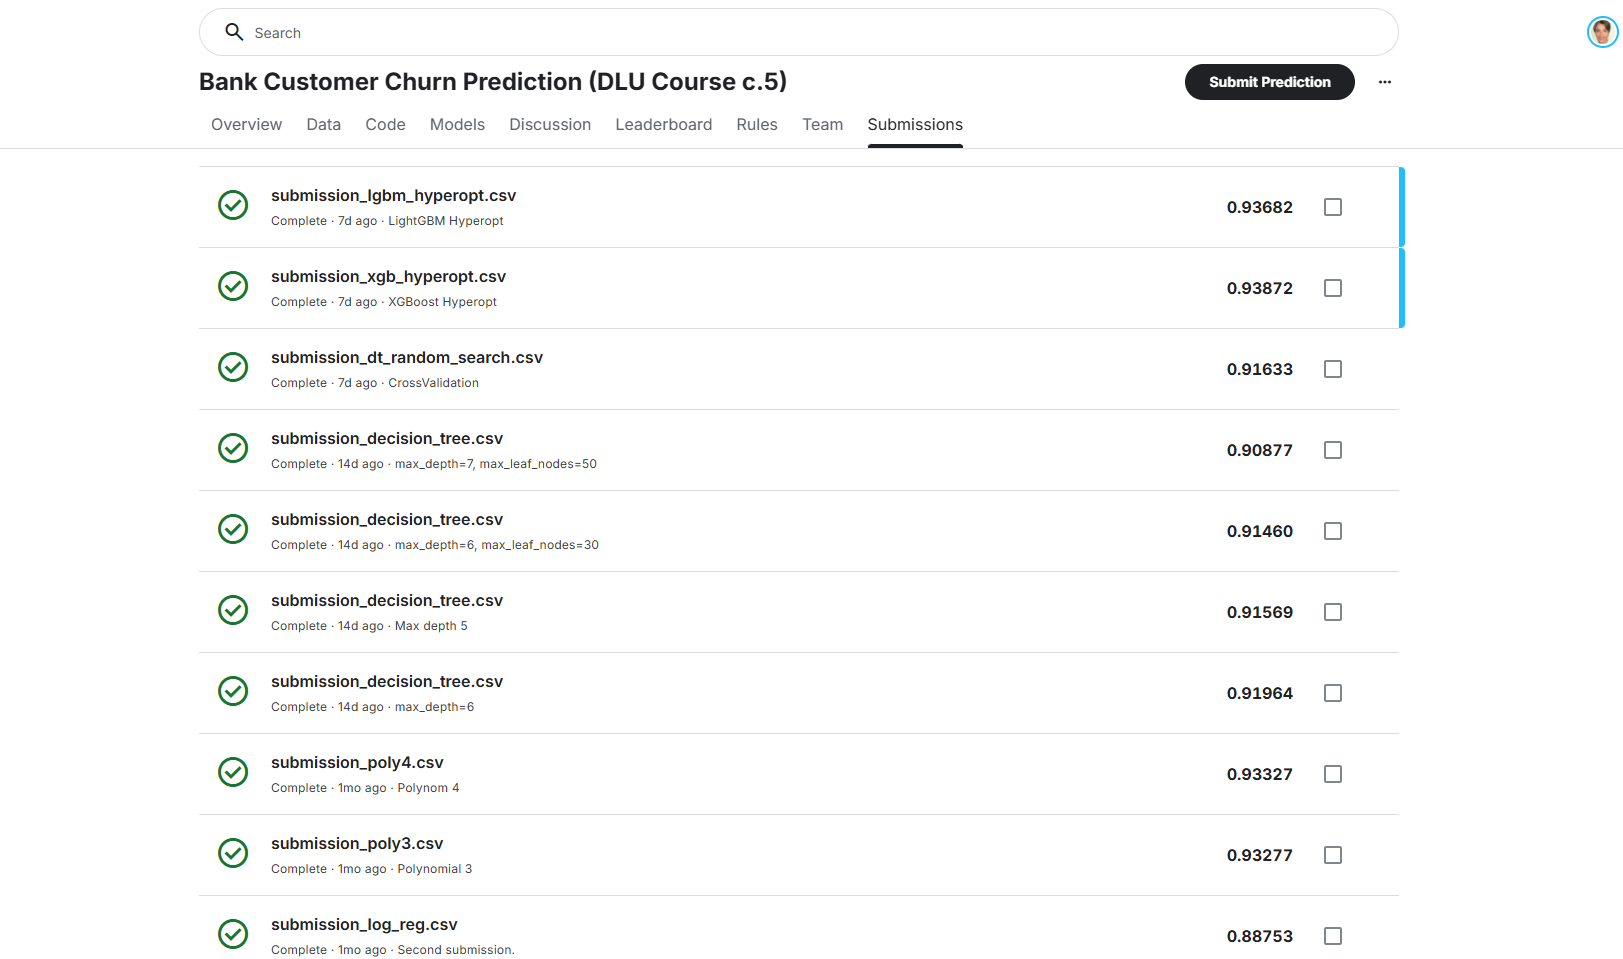